In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## File Input

Remember the files from the last notebook:

In [ ]:
project_name = "input_file"
BOLTZ_WORKING_DIR = Path("boltz_test")

In [3]:
# Define the base directory
BOLTZ_RESULTS = BOLTZ_WORKING_DIR / f"boltz_results_{project_name}"
BOLTZ_PREDICTIONS = BOLTZ_RESULTS / "predictions" / project_name

# Construct file paths
summary_file = BOLTZ_PREDICTIONS / f"confidence_{project_name}_model_0.json"
plddt_file = BOLTZ_PREDICTIONS / f"plddt_{project_name}_model_0.npz"
pae_file = BOLTZ_PREDICTIONS / f"pae_{project_name}_model_0.npz"

# Open files
with open(summary_file) as file:
    confidence = json.load(file)

plddt_file = np.load(plddt_file)
pae_file = np.load(pae_file)

In [4]:
# translate chain indices
chains = [chr(item) for item in range(ord("A"), ord("Z") + 1)][
    : len(confidence["chains_ptm"])
]

## Residue Level Confidence

The Predicted Local Distance Difference Test (pLDDT) is a per residue value typically scaled between 0 and 1 or 0 and 100. A pLDDT above 90 is considered near atomic level precision of the prediction. Between 70 and 90 is considered a high confidence in the prediction. Below 70 a low confidence is observed and below 50 a very low confidence.

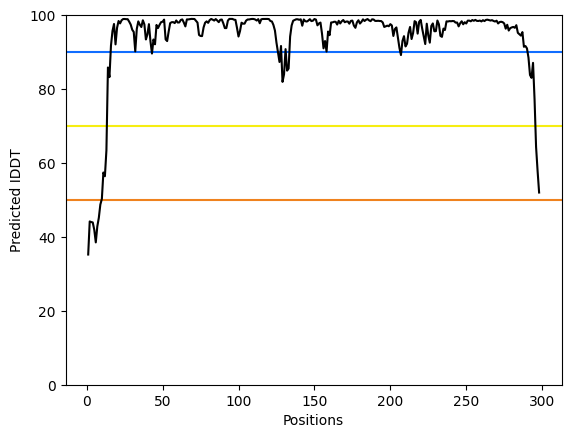

In [5]:
y = plddt_file["plddt"] * 100
x = np.arange(1, len(y) + 1)

regions = [
    {"label": "Very High", "color": "#106dff", "bottom": 90, "top": 100},
    {"label": "Confident", "color": "#f6ed12", "bottom": 70, "top": 90},
    {"label": "Low", "color": "#ef821e", "bottom": 50, "top": 70},
]

# Add colored horizontal lines for each confidence interval
for region in regions:
    plt.axhline(region["bottom"], color=region["color"])

plt.plot(x, y, color="black")

plt.ylim(0, 100)
plt.xlabel("Positions")
plt.ylabel("Predicted IDDT")

plt.show()

The **predicted aligned error (PAE)** is an estimate of the error in the relative postion and orientation between two residues, molecules or ions in the predicted structure. Higher values indicate lower confidence.

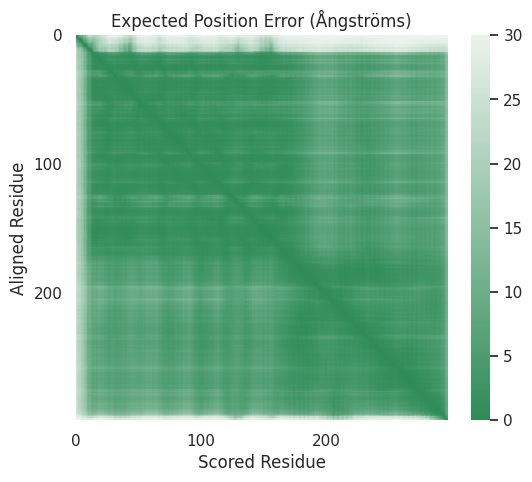

In [6]:
sns.set_theme(rc={"figure.figsize": (6, 5)})

ax = sns.heatmap(
    pae_file["pae"],
    xticklabels=100,
    yticklabels=100,
    cmap=sns.light_palette("seagreen", reverse=True, as_cmap=True),
    vmin=0,
    vmax=30,
)
ax.tick_params(left=False, bottom=False)
ax.set_title("Expected Position Error (Ångströms)")

plt.yticks(rotation=0)
plt.xlabel("Scored Residue")
plt.ylabel("Aligned Residue")

plt.show()

## Global Confidence Levels


The predicted template modeling (pTM) score measures the accuracy of the entire structure. It ranges from 0-1. A pTM score above 0.5 means the overal predicted ford for the complex might be similar to the true structure.
For more information see https://doi.org/10.1093/BIOINFORMATICS/BTQ066.

Note that TM score is strict for small structures or short chains (fewer than 20 tolkens). For these cases PAE and pLDDT may be more indicative of prediction quality.

In [7]:
round(confidence["ptm"], 2)

0.84

The interface predicted template modeling (ipTM) score measures accuracy of the predicted relative positions of the subunits within a complex. It ranges from 0 to 1. Values higher than 0.8 represent confident high-quality predictions, while values below 0.6 suggest likely a failed prediction.

Note that this is 0.0 if there is only one chain in the input file.

In [8]:
round(confidence["iptm"], 2)

0.0

## Aggregated Confidence Levels

The confidence levels can be aggregated over different components of the final model. The **ligand ipTM** and **protein ipTM** allow to distinguish between the accuracy of ligands and protein components, respectively.

Note that these are 0.0 if there is only one chain in the input file.

In [9]:
round(confidence["ligand_iptm"], 2), round(confidence["protein_iptm"], 2)

(0.0, 0.0)

## Chain Confidence Levels

Chain confidence levels allow a breakdown of the overall confidence levels onto individual chains. The **chain pTM** contains the pTM restricted to the respective chain. This can be used for ranking individual chains, independent of their interactions. The **chain ipTM** gives the average confidence per chain in the interface between each chain and all other chains. It can be used to ranking specific chains with a focus on their interaction with the rest of the complex. This is often the case for ligands. 

Note that the chain ipTM is not available for ions.

In [10]:
chain_confidence = pd.DataFrame.from_dict(
    data=confidence["chains_ptm"], columns=["Chain pTM Score"], orient="index"
)
chain_confidence.index = chains
chain_confidence

,Chain pTM Score
A,0.843053


## Chain Pair Confidence Levels
Chain pair confidence levels show values with respect to all other individual chains in matrix format.

The diagonal elements (i, i) contain the **pTM** restricted to chain i. Off-diagonal elements (i, j) of the array contain the **ipTM** restricted to tokens from chains i and j.  This inforamtion can be used for ranking a specific interface between two chains, when you know that they interact, e.g. for antibody-antigen interactions.

Note that the chain restrictred pTM and ipTM are not available for ions.

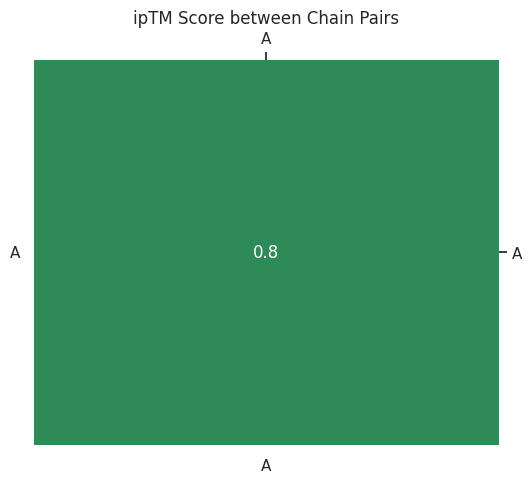

In [11]:
chain_pair_iptm = pd.DataFrame(confidence["pair_chains_iptm"])
chain_pair_iptm.index = chains
chain_pair_iptm.columns = chains

ax = sns.heatmap(
    chain_pair_iptm,
    annot=True,
    fmt=".1f",
    cmap=sns.light_palette("seagreen", as_cmap=True),
    vmin=0.6,
    vmax=0.8,
    cbar=False,
)
ax.tick_params(right=True, top=True, labelright=True, labeltop=True, rotation=0)
ax.set_title("ipTM Score between Chain Pairs")

plt.show()